# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Keisya Nazalia Azally
- **Email:** cdcc008d6x1397@student.devacademy.id
- **ID Dicoding:** keisya_nazalia_azally_5hPn

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1

Bagaimana pengaruh musim dan kondisi cuaca terhadap rata-rata jumlah peminjaman sepeda?

- Pertanyaan 2

Bagaimana pola peminjaman sepeda berdasarkan jam operasional, serta perbedaannya antara hari kerja dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from babel.numbers import format_currency

sns.set(style='dark')

## Data Wrangling

### Gathering Data

In [55]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

**Insight:**
- Jumlah peminjaman sepeda dipengaruhi oleh faktor waktu dan aktivitas harian, di mana penggunaan cenderung lebih tinggi pada hari kerja serta mengikuti pola jam tertentu (rendah di dini hari dan meningkat pada jam aktivitas).
- Faktor lingkungan seperti kondisi cuaca dan suhu juga berpengaruh, di mana cuaca yang lebih baik dan suhu yang nyaman cenderung meningkatkan jumlah peminjaman sepeda.

### Assessing Data

In [56]:
day_df.info()
day_df.isna().sum()
day_df.duplicated().sum()

hour_df.info()
hour_df.isna().sum()
hour_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

0

**Insight:**
- Dataset harian (day.csv) dan per jam (hour.csv) memiliki data yang lengkap tanpa missing values maupun duplikasi, sehingga data dapat langsung digunakan untuk analisis tanpa perlu penanganan data hilang atau redundansi.
- Struktur data sudah konsisten dengan tipe data yang sesuai (numerik dan kategorikal), namun kolom tanggal (dteday) masih bertipe object sehingga perlu dikonversi ke format datetime agar analisis berbasis waktu dapat dilakukan dengan lebih optimal.

### Cleaning Data

In [57]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

season_map = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weather_map = {
    1: "Clear",
    2: "Mist/Cloudy",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}

day_df["season"] = day_df["season"].map(season_map)
day_df["weathersit"] = day_df["weathersit"].map(weather_map)

hour_df["season"] = hour_df["season"].map(season_map)
hour_df["weathersit"] = hour_df["weathersit"].map(weather_map)

**Insight:**
- Proses cleaning data dilakukan dengan mengubah tipe data kolom tanggal (dteday) menjadi format datetime serta mengonversi kode numerik seperti season dan weathersit menjadi label kategorikal agar data lebih mudah dipahami dan dianalisis.
- Setelah proses pembersihan, dataset menjadi lebih terstruktur dan siap digunakan untuk analisis lanjutan, khususnya dalam mengeksplorasi pola berbasis waktu dan kondisi lingkungan.

## Exploratory Data Analysis (EDA)

### Explore ...

In [58]:
season_rentals = day_df.groupby("season")["cnt"].mean()
weather_rentals = day_df.groupby("weathersit")["cnt"].mean()

season_rentals
weather_rentals

hourly_rentals = hour_df.groupby("hr")["cnt"].mean()

workingday_rentals = hour_df.groupby(["workingday", "hr"])["cnt"].mean().reset_index()

**Insight:**
- Jumlah peminjaman sepeda tertinggi terjadi pada kondisi cuaca cerah (Clear), menunjukkan bahwa pengguna cenderung lebih aktif menggunakan sepeda saat kondisi lingkungan mendukung.
- Pada kondisi cuaca yang lebih buruk seperti Light Rain/Snow, jumlah peminjaman menurun secara signifikan, yang mengindikasikan bahwa cuaca memiliki pengaruh besar terhadap minat penggunaan layanan bike sharing.
- Pola peminjaman sepeda menunjukkan adanya jam sibuk (peak hours), di mana jumlah peminjaman meningkat pada jam-jam tertentu dalam sehari dan menurun pada dini hari, mencerminkan pola aktivitas harian pengguna.
- Pada hari kerja (workingday), peminjaman sepeda cenderung lebih tinggi pada jam-jam sibuk dibandingkan hari libur, yang mengindikasikan bahwa sepeda banyak digunakan sebagai sarana transportasi rutin seperti berangkat dan pulang kerja.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

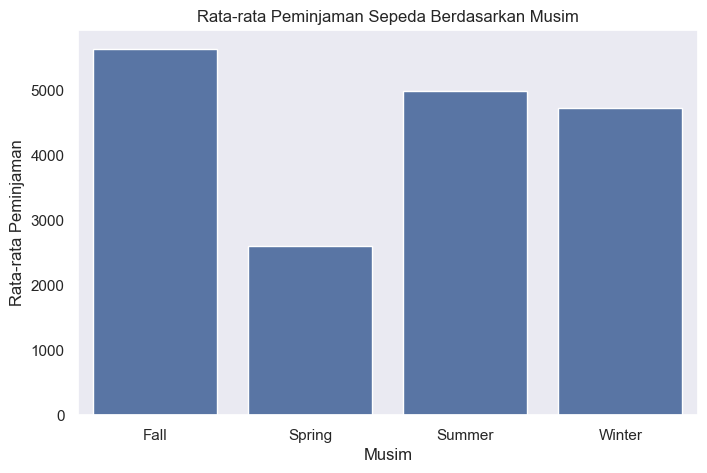

In [59]:
plt.figure(figsize=(8,5))
sns.barplot(x=season_rentals.index, y=season_rentals.values)
plt.title("Rata-rata Peminjaman Sepeda Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Peminjaman")
plt.show()

### Pertanyaan 2:

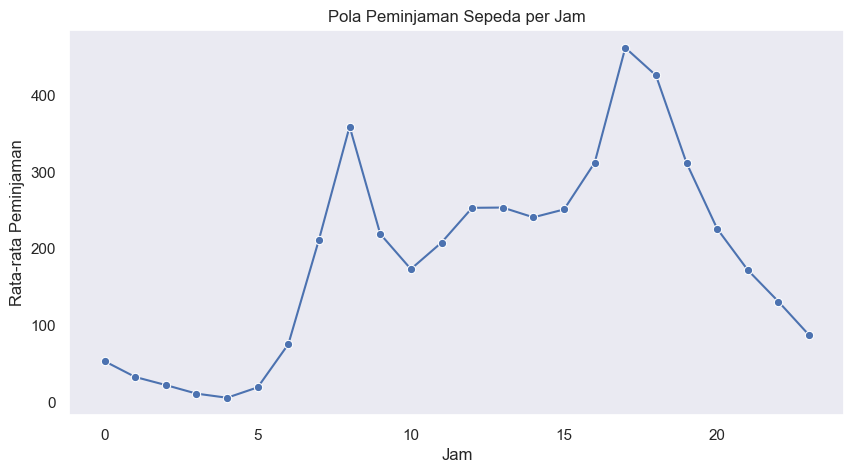

In [60]:
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_rentals.index, y=hourly_rentals.values, marker="o")
plt.title("Pola Peminjaman Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Peminjaman")
plt.show()

**Insight:**
- Rata-rata peminjaman sepeda tertinggi terjadi pada musim Fall, diikuti oleh Summer dan Winter, sedangkan Spring memiliki jumlah peminjaman terendah, yang menunjukkan bahwa kondisi musim berpengaruh terhadap tingkat penggunaan sepeda.
- Pola peminjaman per jam menunjukkan dua puncak utama, yaitu pada pagi hari (sekitar jam 8) dan sore hari (sekitar jam 17–18), yang mengindikasikan bahwa sepeda banyak digunakan untuk aktivitas rutin seperti berangkat dan pulang kerja.

## Analisis Lanjutan (Opsional)

In [61]:
day_df["demand_category"] = pd.cut(
    day_df["cnt"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

## Conclusion

- Conclusion Pertanyaan 1

Musim dan kondisi cuaca memiliki pengaruh signifikan terhadap jumlah peminjaman sepeda. Peminjaman tertinggi terjadi pada musim Fall dan kondisi cuaca cerah, sedangkan kondisi cuaca buruk seperti hujan atau salju menurunkan jumlah peminjaman. Hal ini menunjukkan bahwa faktor lingkungan sangat memengaruhi minat penggunaan layanan bike sharing.

- Conclusion Pertanyaan 2

Pola peminjaman sepeda menunjukkan adanya jam sibuk pada pagi dan sore hari, terutama pada hari kerja. Hal ini mengindikasikan bahwa sepeda banyak digunakan sebagai sarana transportasi rutin untuk aktivitas harian seperti berangkat dan pulang kerja.